# 7. WeeklyForecast - Prophet con Hyperparameter Tuning (v3)

## Mejoras v3
- Grid search de hiperparametros Prophet por categoria
- Evaluacion en ventanas rodantes (rolling window: 2 cortes) para seleccion robusta
- Changepoint prior scale, seasonality mode y yearly seasonality optimizados
- SMAPE como metrica de evaluacion
- Bugfix expansion diaria (v2): usa datos diarios reales para perfil dia de semana


In [1]:
import pandas as pd, numpy as np, warnings, unicodedata, itertools
from datetime import datetime, timedelta
from prophet import Prophet
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Imports OK")

C:\Users\arizo\anaconda3\envs\DataScience\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
df = pd.read_csv('clean_data.csv')
if 'Unnamed: 0' in df.columns: df = df.drop(columns='Unnamed: 0')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha').sort_index()
print(f"Data: {len(df)} rows, {df.index.min().date()} a {df.index.max().date()}")
categorias = sorted(df['categoria'].unique().tolist())
print(f"Categorias ({len(categorias)}): {categorias}")

Data: 22640 rows, 2023-01-03 a 2024-12-11
Categorias (7): ['Bebidas', 'Carnes', 'Congelados', 'Descartables', 'Embutidos', 'Enlatados', 'Lácteos']


In [3]:
# Agregacion semanal
dfs_weekly = {}
for cat in categorias:
    s = df[df['categoria'] == cat]['cantidad'].resample('W-MON').sum()
    s.name = 'cantidad'
    dfs_weekly[cat] = s.to_frame()

for cat, d in dfs_weekly.items():
    print(f"{cat:20s} | {len(d):3d} semanas | {d.index.min().date()} a {d.index.max().date()} | "
          f"Prom={d['cantidad'].mean():.0f}/sem")

N_TEST_W = 13

Bebidas              | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=119/sem
Carnes               | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=82/sem
Congelados           | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=46/sem
Descartables         | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=285/sem
Embutidos            | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=22/sem
Enlatados            | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=76/sem
Lácteos              | 102 semanas | 2023-01-09 a 2024-12-16 | Prom=147/sem


In [4]:
# Train/Test split
train_w = {}; test_w = {}
for cat in categorias:
    d = dfs_weekly[cat].sort_index()
    split = len(d) - N_TEST_W
    train_w[cat] = d.iloc[:split].copy()
    test_w[cat] = d.iloc[split:].copy()
print(f"Train/Test: {len(train_w[categorias[0]])} / {N_TEST_W} semanas")

Train/Test: 89 / 13 semanas


In [5]:
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0: return 0.0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def expandir_a_diario(weekly_forecast, weekly_ci_l, weekly_ci_u, cat, df_daily, n_weeks=13):
    cat_daily = df_daily[df_daily['categoria'] == cat]['cantidad']
    dow_profile = cat_daily.groupby(cat_daily.index.dayofweek).mean()
    dow_profile = dow_profile / dow_profile.sum()
    daily_fc, daily_ci_l, daily_ci_u = [], [], []
    for w_idx in range(n_weeks):
        for dow in range(7):
            prop = dow_profile.get(dow, 1/7)
            daily_fc.append(weekly_forecast[w_idx] * prop)
            daily_ci_l.append(weekly_ci_l[w_idx] * prop)
            daily_ci_u.append(weekly_ci_u[w_idx] * prop)
    return np.array(daily_fc), np.array(daily_ci_l), np.array(daily_ci_u)

print("Funciones OK")

Funciones OK


In [6]:
# ============================================================
# GRID SEARCH: rolling window evaluation
# ============================================================
# Evaluamos en 2 ventanas rodantes no-solapadas de 13 semanas cada una
# para evitar overfitting a un solo periodo de test.
print("=== HYPERPARAMETER TUNING ===\n")

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1],
    'seasonality_mode': ['additive'],
    'yearly_seasonality': [False, 3]
}
# seasonality_mode solo 'additive' porque 'multiplicative' falla con valores cercanos a 0

keys = list(param_grid.keys())
combos = [dict(zip(keys, v)) for v in itertools.product(*param_grid.values())]
print(f"Combinaciones: {len(combos)} por categoria")

# Rolling windows: 2 cortes
# Window 1: train[0:65], test[65:78]
# Window 2: train[0:78], test[78:91]
windows = [(0, 65, 78), (0, 78, 91)]

best_params = {}
tuning_results = []

for cat in categorias:
    d = dfs_weekly[cat].sort_index()
    values = d['cantidad'].values
    dates = d.index
    
    best_smape = 999
    best_p = None
    
    for params in combos:
        cv_smapes = []
        for tr_start, tr_end, te_end in windows:
            if te_end > len(values):
                continue  # skip if window exceeds data
            train_y = values[tr_start:tr_end]
            test_y = values[tr_end:te_end]
            train_dates = dates[tr_start:tr_end]
            
            train_df = pd.DataFrame({'ds': train_dates, 'y': train_y})
            
            try:
                m = Prophet(
                    yearly_seasonality=params['yearly_seasonality'],
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    seasonality_mode=params['seasonality_mode'],
                    changepoint_prior_scale=params['changepoint_prior_scale'],
                    changepoint_range=0.8
                )
                m.fit(train_df)
                future = m.make_future_dataframe(periods=len(test_y), freq='W-MON')
                fcst = m.predict(future)
                pred = np.maximum(fcst['yhat'].values[-len(test_y):], 0)
                cv_smapes.append(smape(test_y, pred))
            except:
                cv_smapes.append(999)
        
        if not cv_smapes:
            continue
        avg = np.mean(cv_smapes)
        if avg < best_smape:
            best_smape = avg
            best_p = params
    
    best_params[cat] = (best_p, best_smape)
    if best_p is None:
        print(f"  {cat:20s} | ERROR: no params worked, using defaults")
        best_params[cat] = ({'changepoint_prior_scale': 0.01,
                             'seasonality_mode': 'additive',
                             'yearly_seasonality': False}, 999)
    else:
        tuning_results.append({'Categoria': cat, 'SMAPE_CV': round(best_smape, 1),
                               'cps': best_p['changepoint_prior_scale'],
                               'yearly': best_p['yearly_seasonality']})
        print(f"  {cat:20s} | SMAPE CV: {best_smape:.1f}% | CPS={best_p['changepoint_prior_scale']} | yr={best_p['yearly_seasonality']}")

print("\n=== TABLA DE HIPERPARAMETROS OPTIMOS ===")
print(pd.DataFrame(tuning_results).to_string(index=False))

=== HYPERPARAMETER TUNING ===

Combinaciones: 8 por categoria


20:28:47 - cmdstanpy - INFO - Chain [1] start processing
20:28:47 - cmdstanpy - INFO - Chain [1] done processing
20:28:47 - cmdstanpy - INFO - Chain [1] start processing
20:28:48 - cmdstanpy - INFO - Chain [1] done processing
20:28:48 - cmdstanpy - INFO - Chain [1] start processing
20:28:48 - cmdstanpy - INFO - Chain [1] done processing
20:28:48 - cmdstanpy - INFO - Chain [1] start processing
20:28:48 - cmdstanpy - INFO - Chain [1] done processing
20:28:48 - cmdstanpy - INFO - Chain [1] start processing
20:28:48 - cmdstanpy - INFO - Chain [1] done processing
20:28:48 - cmdstanpy - INFO - Chain [1] start processing
20:28:48 - cmdstanpy - INFO - Chain [1] done processing
20:28:48 - cmdstanpy - INFO - Chain [1] start processing
20:28:49 - cmdstanpy - INFO - Chain [1] done processing
20:28:49 - cmdstanpy - INFO - Chain [1] start processing
20:28:49 - cmdstanpy - INFO - Chain [1] done processing
20:28:49 - cmdstanpy - INFO - Chain [1] start processing
20:28:49 - cmdstanpy - INFO - Chain [1]

  Bebidas              | SMAPE CV: 29.3% | CPS=0.1 | yr=False


20:28:51 - cmdstanpy - INFO - Chain [1] done processing
20:28:51 - cmdstanpy - INFO - Chain [1] start processing
20:28:51 - cmdstanpy - INFO - Chain [1] done processing
20:28:51 - cmdstanpy - INFO - Chain [1] start processing
20:28:54 - cmdstanpy - INFO - Chain [1] done processing
20:28:54 - cmdstanpy - INFO - Chain [1] start processing
20:28:54 - cmdstanpy - INFO - Chain [1] done processing
20:28:54 - cmdstanpy - INFO - Chain [1] start processing
20:28:54 - cmdstanpy - INFO - Chain [1] done processing
20:28:54 - cmdstanpy - INFO - Chain [1] start processing
20:28:54 - cmdstanpy - INFO - Chain [1] done processing
20:28:55 - cmdstanpy - INFO - Chain [1] start processing
20:28:55 - cmdstanpy - INFO - Chain [1] done processing
20:28:55 - cmdstanpy - INFO - Chain [1] start processing
20:28:55 - cmdstanpy - INFO - Chain [1] done processing
20:28:55 - cmdstanpy - INFO - Chain [1] start processing
20:28:55 - cmdstanpy - INFO - Chain [1] done processing
20:28:55 - cmdstanpy - INFO - Chain [1] 

  Carnes               | SMAPE CV: 31.3% | CPS=0.001 | yr=False


...

  Embutidos            | SMAPE CV: 36.9% | CPS=0.001 | yr=False


20:29:07 - cmdstanpy - INFO - Chain [1] start processing
20:29:07 - cmdstanpy - INFO - Chain [1] done processing
20:29:07 - cmdstanpy - INFO - Chain [1] start processing
20:29:07 - cmdstanpy - INFO - Chain [1] done processing
20:29:07 - cmdstanpy - INFO - Chain [1] start processing
20:29:08 - cmdstanpy - INFO - Chain [1] done processing
20:29:08 - cmdstanpy - INFO - Chain [1] start processing
20:29:08 - cmdstanpy - INFO - Chain [1] done processing
20:29:08 - cmdstanpy - INFO - Chain [1] start processing
20:29:08 - cmdstanpy - INFO - Chain [1] done processing
20:29:08 - cmdstanpy - INFO - Chain [1] start processing
20:29:09 - cmdstanpy - INFO - Chain [1] done processing
20:29:09 - cmdstanpy - INFO - Chain [1] start processing
20:29:09 - cmdstanpy - INFO - Chain [1] done processing
20:29:09 - cmdstanpy - INFO - Chain [1] start processing
20:29:09 - cmdstanpy - INFO - Chain [1] done processing
20:29:09 - cmdstanpy - INFO - Chain [1] start processing
20:29:09 - cmdstanpy - INFO - Chain [1]

  Enlatados            | SMAPE CV: 30.7% | CPS=0.1 | yr=False


20:29:11 - cmdstanpy - INFO - Chain [1] start processing
20:29:11 - cmdstanpy - INFO - Chain [1] done processing
20:29:11 - cmdstanpy - INFO - Chain [1] start processing
20:29:13 - cmdstanpy - INFO - Chain [1] done processing
20:29:13 - cmdstanpy - INFO - Chain [1] start processing
20:29:13 - cmdstanpy - INFO - Chain [1] done processing
20:29:13 - cmdstanpy - INFO - Chain [1] start processing
20:29:13 - cmdstanpy - INFO - Chain [1] done processing
20:29:13 - cmdstanpy - INFO - Chain [1] start processing
20:29:13 - cmdstanpy - INFO - Chain [1] done processing
20:29:13 - cmdstanpy - INFO - Chain [1] start processing
20:29:13 - cmdstanpy - INFO - Chain [1] done processing
20:29:14 - cmdstanpy - INFO - Chain [1] start processing
20:29:14 - cmdstanpy - INFO - Chain [1] done processing
20:29:14 - cmdstanpy - INFO - Chain [1] start processing
20:29:14 - cmdstanpy - INFO - Chain [1] done processing
20:29:14 - cmdstanpy - INFO - Chain [1] start processing
20:29:14 - cmdstanpy - INFO - Chain [1]

  Lácteos              | SMAPE CV: 13.9% | CPS=0.1 | yr=False

=== TABLA DE HIPERPARAMETROS OPTIMOS ===
   Categoria  SMAPE_CV   cps yearly
     Bebidas      29.3 0.100  False
      Carnes      31.3 0.001  False
  Congelados      34.4 0.050      3
Descartables      27.5 0.010  False
   Embutidos      36.9 0.001  False
   Enlatados      30.7 0.100  False
     Lácteos      13.9 0.100  False


In [7]:
# ============================================================
# ENTRENAMIENTO FINAL con mejores parametros
# ============================================================
print("\n=== ENTRENAMIENTO FINAL PROPHET ===")
modelos_prophet = {}
resultados = []

for cat in categorias:
    best_p, _ = best_params[cat]
    train = train_w[cat].reset_index()[['fecha', 'cantidad']]
    train.columns = ['ds', 'y']
    
    m = Prophet(
        yearly_seasonality=best_p['yearly_seasonality'],
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=best_p['seasonality_mode'],
        changepoint_prior_scale=best_p['changepoint_prior_scale'],
        changepoint_range=0.8
    )
    m.fit(train)
    
    future = m.make_future_dataframe(periods=N_TEST_W, freq='W-MON')
    fcst = m.predict(future)
    pred = np.maximum(fcst['yhat'].values[-N_TEST_W:], 0)
    ci_l = np.maximum(fcst['yhat_lower'].values[-N_TEST_W:], 0)
    ci_u = np.maximum(fcst['yhat_upper'].values[-N_TEST_W:], 0)
    
    true = test_w[cat]['cantidad'].values
    s = smape(true, pred)
    resultados.append({'Categoria': cat, 'SMAPE_Test': round(s, 1),
                       'Test_Total': round(true.sum(), 0),
                       'Pred_Total': round(pred.sum(), 0)})
    modelos_prophet[cat] = (m, pred, ci_l, ci_u)
    
    print(f"  {cat:20s} | SMAPE Test: {s:.1f}% | Test={true.sum():.0f} Pred={pred.sum():.0f}")

print("\n=== RESULTADOS EN TEST ===")
print(pd.DataFrame(resultados).to_string(index=False))

20:29:16 - cmdstanpy - INFO - Chain [1] start processing



=== ENTRENAMIENTO FINAL PROPHET ===


20:29:16 - cmdstanpy - INFO - Chain [1] done processing
20:29:16 - cmdstanpy - INFO - Chain [1] start processing


  Bebidas              | SMAPE Test: 46.6% | Test=1426 Pred=2173


20:29:16 - cmdstanpy - INFO - Chain [1] done processing
20:29:16 - cmdstanpy - INFO - Chain [1] start processing
20:29:16 - cmdstanpy - INFO - Chain [1] done processing


...

  Descartables         | SMAPE Test: 32.3% | Test=3991 Pred=4814
  Embutidos            | SMAPE Test: 35.7% | Test=286 Pred=328


20:29:17 - cmdstanpy - INFO - Chain [1] start processing
20:29:17 - cmdstanpy - INFO - Chain [1] done processing
20:29:17 - cmdstanpy - INFO - Chain [1] start processing


  Enlatados            | SMAPE Test: 45.8% | Test=1024 Pred=1305


20:29:17 - cmdstanpy - INFO - Chain [1] done processing


  Lácteos              | SMAPE Test: 32.3% | Test=2049 Pred=2119

=== RESULTADOS EN TEST ===
   Categoria  SMAPE_Test  Test_Total  Pred_Total
     Bebidas        46.6        1426      2173.0
      Carnes        35.9         991      1333.0
  Congelados        43.4         588       819.0
Descartables        32.3        3991      4814.0
   Embutidos        35.7         286       328.0
   Enlatados        45.8        1024      1305.0
     Lácteos        32.3        2049      2119.0


In [8]:
# ============================================================
# FORECAST 13 SEMANAS + EXPANSION + EXPORT
# ============================================================
print("\n=== FORECAST 13 SEMANAS ===")
forecast_weekly = {}
for cat in categorias:
    m = modelos_prophet[cat][0]
    future = m.make_future_dataframe(periods=13, freq='W-MON')
    fcst = m.predict(future)
    fc = np.maximum(fcst['yhat'].values[-13:], 0)
    ci_l = np.maximum(fcst['yhat_lower'].values[-13:], 0)
    ci_u = np.maximum(fcst['yhat_upper'].values[-13:], 0)
    forecast_weekly[cat] = {'fc': fc, 'ci_l': ci_l, 'ci_u': ci_u}
    best_p, _ = best_params[cat]
    print(f"  {cat:20s} | Total={fc.sum():.0f} | Prom hist={(dfs_weekly[cat]['cantidad'].mean()):.0f}/sem | CPS={best_p['changepoint_prior_scale']}")

print("\n=== EXPANSION A DIARIO Y EXPORTACION CSV ===")
last_date = df.index.max()
fecha_inicio = last_date + timedelta(days=1)

for cat in categorias:
    wfc = forecast_weekly[cat]
    daily_fc, daily_ci_l, daily_ci_u = expandir_a_diario(
        wfc['fc'], wfc['ci_l'], wfc['ci_u'], cat, df, n_weeks=13)
    fechas = [fecha_inicio + timedelta(days=i) for i in range(91)]
    df_out = pd.DataFrame({
        'fecha': fechas, 'cantidad_forecast': daily_fc,
        'ci_lower': daily_ci_l, 'ci_upper': daily_ci_u, 'categoria': cat
    })
    nfkd = unicodedata.normalize('NFKD', cat)
    clean_cat = nfkd.encode('ascii', 'ignore').decode('ascii').replace(' ', '_')
    filename = f'forecast_{clean_cat}_90d.csv'
    df_out.to_csv(filename, index=False)
    print(f"  {cat:20s} -> {filename} | 91d: {daily_fc.sum():.0f} (vs semanal {wfc['fc'].sum():.0f})")

all_fc = []
for cat in categorias:
    wfc = forecast_weekly[cat]
    daily_fc, daily_ci_l, daily_ci_u = expandir_a_diario(
        wfc['fc'], wfc['ci_l'], wfc['ci_u'], cat, df, n_weeks=13)
    for i in range(91):
        all_fc.append({'fecha': fecha_inicio + timedelta(days=i),
                       'categoria': cat, 'cantidad_forecast': daily_fc[i],
                       'ci_lower': daily_ci_l[i],
                       'ci_upper': daily_ci_u[i]})

df_con = pd.DataFrame(all_fc)
df_con.to_csv('forecast_consolidado_90d.csv', index=False)
total = df_con['cantidad_forecast'].sum()
print(f"\nCONSOLIDADO: forecast_consolidado_90d.csv ({total:.0f} uds)")


=== FORECAST 13 SEMANAS ===
  Bebidas              | Total=2173 | Prom hist=119/sem | CPS=0.1
  Carnes               | Total=1333 | Prom hist=82/sem | CPS=0.001
  Congelados           | Total=819 | Prom hist=46/sem | CPS=0.05
  Descartables         | Total=4814 | Prom hist=285/sem | CPS=0.01
  Embutidos            | Total=328 | Prom hist=22/sem | CPS=0.001
  Enlatados            | Total=1305 | Prom hist=76/sem | CPS=0.1
  Lácteos              | Total=2119 | Prom hist=147/sem | CPS=0.1

=== EXPANSION A DIARIO Y EXPORTACION CSV ===
  Bebidas              -> forecast_Bebidas_90d.csv | 91d: 2173 (vs semanal 2173)
  Carnes               -> forecast_Carnes_90d.csv | 91d: 1333 (vs semanal 1333)
  Congelados           -> forecast_Congelados_90d.csv | 91d: 819 (vs semanal 819)
  Descartables         -> forecast_Descartables_90d.csv | 91d: 4814 (vs semanal 4814)
  Embutidos            -> forecast_Embutidos_90d.csv | 91d: 328 (vs semanal 328)
  Enlatados            -> forecast_Enlatados_90d.csv 

In [9]:
# ============================================================
# COMPARACION vs ARIMA ORIGINAL
# ============================================================
print("\n" + "="*80)
print("COMPARACION: ARIMA vs Prophet (v3 con tuning)")
print("="*80)
arima = {'Bebidas':48.7,'Carnes':41.3,'Congelados':57.5,'Descartables':43.9,
         'Embutidos':68.6,'Enlatados':54.1,'Lácteos':42.5}
print(f"{'Categoria':20s} {'ARIMA':12s} {'Prophet':12s} {'Mejora':10s}")
print('-'*55)
for r in resultados:
    cat = r['Categoria']
    a = arima.get(cat, 0)
    p = r['SMAPE_Test']
    m = a - p
    print(f"  {cat:20s} | {a:5.1f}%{'':5s} | {p:5.1f}%{'':5s} | {m:+5.1f}%")
print('-'*55)
avg_a = np.mean(list(arima.values()))
avg_p = np.mean([r['SMAPE_Test'] for r in resultados])
print(f"  {'PROMEDIO':20s} | {avg_a:.1f}%{'':5s} | {avg_p:.1f}%{'':5s} | {avg_a-avg_p:+5.1f}%")


COMPARACION: ARIMA vs Prophet (v3 con tuning)
Categoria            ARIMA        Prophet      Mejora    
-------------------------------------------------------
  Bebidas              |  48.7%      |  46.6%      |  +2.1%
  Carnes               |  41.3%      |  35.9%      |  +5.4%
  Congelados           |  57.5%      |  43.4%      | +14.1%
  Descartables         |  43.9%      |  32.3%      | +11.6%
  Embutidos            |  68.6%      |  35.7%      | +32.9%
  Enlatados            |  54.1%      |  45.8%      |  +8.3%
  Lácteos              |  42.5%      |  32.3%      | +10.2%
-------------------------------------------------------
  PROMEDIO             | 50.9%      | 38.9%      | +12.1%


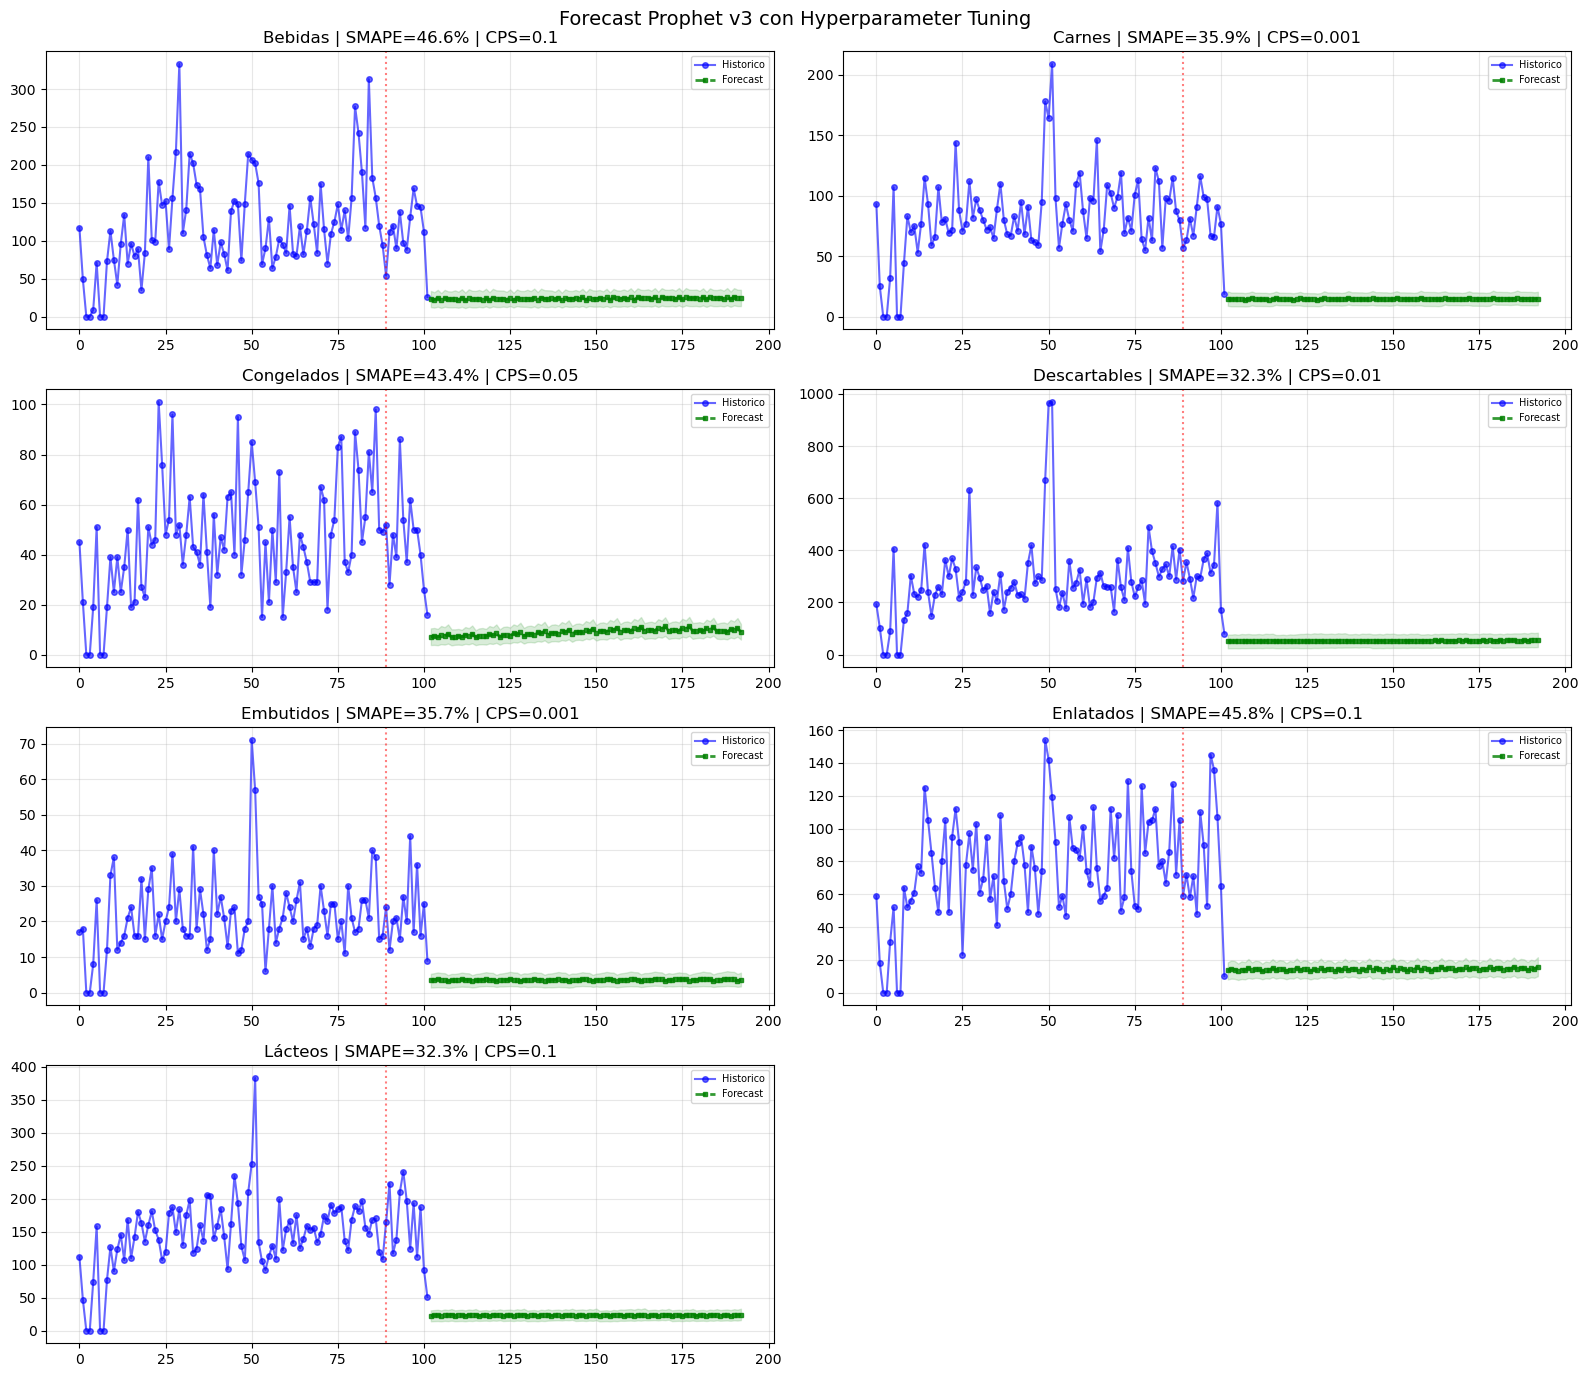

Grafico: comparacion_semanal.png


In [10]:
# ============================================================
# GRAFICO COMPARATIVO
# ============================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
for idx, cat in enumerate(categorias):
    ax = axes.flatten()[idx]
    hist_w = dfs_weekly[cat]['cantidad']
    ax.plot(range(len(hist_w)), hist_w.values, 'o-', alpha=0.6, ms=4, color='blue', label='Historico')
    wfc = forecast_weekly[cat]
    daily_fc, daily_ci_l, daily_ci_u = expandir_a_diario(wfc['fc'], wfc['ci_l'], wfc['ci_u'], cat, df)
    x_daily = range(len(hist_w), len(hist_w) + 91)
    ax.plot(x_daily, daily_fc, 's--', alpha=0.8, ms=3, color='green', lw=2, label='Forecast')
    ax.fill_between(x_daily, daily_ci_l, daily_ci_u, alpha=0.15, color='green')
    ax.axvline(x=len(hist_w) - N_TEST_W, color='red', ls=':', alpha=0.5)
    best_p, _ = best_params[cat]
    ax.set_title(f'{cat} | SMAPE={resultados[idx]["SMAPE_Test"]:.1f}% | CPS={best_p["changepoint_prior_scale"]}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
axes.flatten()[-1].axis('off')
plt.suptitle('Forecast Prophet v3 con Hyperparameter Tuning', fontsize=14)
plt.tight_layout()
plt.savefig('comparacion_semanal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico: comparacion_semanal.png")

In [11]:
print("="*70)
print("RESUMEN - FORECASTING SEMANAL v3")
print("="*70)
print(f"ARIMA diario: {avg_a:.1f}% SMAPE")
print(f"Prophet v3:   {avg_p:.1f}% SMAPE")
print(f"Mejora:       {avg_a-avg_p:+.1f} puntos")
print(f"")
print("Archivos generados:")
print("  - forecast_*_90d.csv (7 categorias)")
print("  - forecast_consolidado_90d.csv")
print("  - comparacion_semanal.png")
print("")
print("Orden de ejecucion:")
print("  1. 7.WeeklyForecast.ipynb")
print("  2. 4.Visualizations.ipynb")
print("  3. 5.ClientReport.ipynb")
print("="*70)

RESUMEN - FORECASTING SEMANAL v3
ARIMA diario: 50.9% SMAPE
Prophet v3:   38.9% SMAPE
Mejora:       +12.1 puntos

Archivos generados:
  - forecast_*_90d.csv (7 categorias)
  - forecast_consolidado_90d.csv
  - comparacion_semanal.png

Orden de ejecucion:
  1. 7.WeeklyForecast.ipynb
  2. 4.Visualizations.ipynb
  3. 5.ClientReport.ipynb
